In [ ]:
import os
import pandas as pd
from collections import defaultdict

# Path to your annotations folder (e.g., the one containing *.txt files)
annotations_dir = "/path/to/mirflickr25k_annotations_v080"

# Path where your images are (we'll map IDs to real file names later)
image_dir = "/path/to/Computer Vision/mirflickr"

# Collect tag-to-image mappings
tag_to_images = defaultdict(set)

for fname in os.listdir(annotations_dir):
    if fname.endswith(".txt") and not fname.startswith("README"):
        tag = fname.split(".")[0].replace("_r1", "").lower()
        with open(os.path.join(annotations_dir, fname), "r") as f:
            for line in f:
                image_id = line.strip()
                if image_id.isdigit():
                    tag_to_images[int(image_id)].add(tag)

# Convert to a structured list
data = []
for image_id, tags in tag_to_images.items():
    image_file = f"im{image_id}.jpg"  # adjust to im{image_id:05d}.jpg if needed
    if os.path.exists(os.path.join(image_dir, image_file)):
        data.append({
            "image": image_file,
            "tags": ",".join(sorted(tags))
        })

# Convert to DataFrame and save
df = pd.DataFrame(data)
df.to_csv("mirflickr25k_annotations_clean.csv", index=False)
print(f"✅ Saved clean annotations: {len(df)} images labeled")

In [1]:
import os
import random
import timm
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from sklearn.metrics import average_precision_score

/home/adevs/anaconda3/envs/CV_Project/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# Utility Functions
# =============================================================================
def l2_normalize(vec):
    norm = np.linalg.norm(vec)
    return vec / norm if norm != 0 else vec

def load_fasttext_embeddings(file_path, label_list, embedding_dim=300):
    embeddings_dict = {}
    label_set = set(label_list)
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split()
            if len(parts) != embedding_dim + 1:
                continue
            word, vec_vals = parts[0], parts[1:]
            if word in label_set:
                vec = np.array([float(x) for x in vec_vals], dtype=np.float32)
                embeddings_dict[word] = l2_normalize(vec)
                if len(embeddings_dict) == len(label_set):
                    break
    return embeddings_dict

def compute_semantic_diversity_weight(pos_embeddings):
    if pos_embeddings.size(0) <= 1:
        return 1.0
    var_vec = torch.var(pos_embeddings, dim=0, unbiased=False)
    return 1.0 + (torch.sum(var_vec) / pos_embeddings.size(1))

def ranking_loss(A, pos_embeddings, neg_embeddings, sdw):
    scores_pos = torch.stack([torch.max(torch.mv(A, pos)) for pos in pos_embeddings])
    scores_neg = torch.stack([torch.max(torch.mv(A, neg)) for neg in neg_embeddings])
    diff = scores_neg.unsqueeze(1) - scores_pos.unsqueeze(0)
    return sdw * torch.log1p(torch.exp(diff)).mean()

def regularization_loss(A):
    return torch.sum(torch.abs(torch.var(A, dim=1, unbiased=False)))

def final_loss(A, pos_embeddings, neg_embeddings, lambda_tilde=0.3):
    sdw = compute_semantic_diversity_weight(pos_embeddings)
    L_rank = ranking_loss(A, pos_embeddings, neg_embeddings, sdw)
    L_reg = regularization_loss(A)
    return (1 - lambda_tilde) * L_rank + (lambda_tilde * neg_embeddings.size(0)) * L_reg


In [3]:
# =============================================================================
# Dataset and Model
# =============================================================================
class MirFlickrDataset(Dataset):
    def __init__(self, df, image_dir, seen_labels, unseen_labels, is_train=True, 
                 transform=None, zero_shot_mode=False):
        self.df = df
        self.image_dir = image_dir
        self.seen_labels = seen_labels
        self.unseen_labels = unseen_labels
        self.is_train = is_train
        self.transform = transform
        self.zero_shot_mode = zero_shot_mode

        if self.is_train:
            self.df = self.df[self.df['tag_list'].apply(
                lambda x: all(tag in seen_labels for tag in x)
            )].reset_index(drop=True)
        else:
            self.df = self.df[self.df['tag_list'].apply(
                lambda x: any(tag in unseen_labels for tag in x)
            )].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_dir, row['image'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        
        tags = row['tag_list']
        if not self.is_train and self.zero_shot_mode:
            tags = [t for t in tags if t in self.unseen_labels]
        return img, tags

In [4]:
# =============================================================================
# Model Defintion
# =============================================================================
class ZSModel(nn.Module):
    def __init__(self, M, d_w, backbone_name="tresnet_m"):
        super().__init__()
        self.M = M
        self.d_w = d_w
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.fc = nn.Linear(self.backbone.num_features, M * d_w)

    def forward(self, x):
        feats = self.backbone(x)
        return self.fc(feats).view(-1, self.M, self.d_w)
    

In [ ]:
# =============================================================================
# Training Setup
# =============================================================================
from sklearn.model_selection import train_test_split

def mirflickr_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    labels = [item[1] for item in batch]
    return images, labels

# Hyperparameters
CSV_PATH = "/path/to/mirflickr25k_annotations_clean.csv"       
IMAGE_DIR = "/path/to/mirflickr"  
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
M = 7
D_W = 300
LAMBDA_TILDE = 0.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Preparation
data_df = pd.read_csv(CSV_PATH)
data_df['tag_list'] = data_df['tags'].str.split(',')
all_labels = data_df['tag_list'].explode().value_counts().index.tolist()


# Choosing the Unseen Values
num_seen = int(0.8 * len(all_labels))
seen_labels = sorted(all_labels[:num_seen])
unseen_labels = set(all_labels[num_seen:])

# Split the seen-only training DataFrame
train_df_full = data_df[data_df['tag_list'].apply(lambda x: all(tag in seen_labels for tag in x))]
train_df, val_df = train_test_split(train_df_full, test_size=0.1, random_state=42)


def load_label_embeddings(label_list, embedding_dim=300, fasttext_path="wiki-news-300d-1M.vec"):
    """Improved with fallback options for missing embeddings"""
    # Try loading from FastText
    embeddings_dict = load_fasttext_embeddings(fasttext_path, label_list, embedding_dim)
    
    # Calculate mean of found embeddings for fallback
    found_embeddings = list(embeddings_dict.values())
    mean_embedding = np.mean(found_embeddings, axis=0) if found_embeddings else np.random.randn(embedding_dim)
    
    # Ensure all labels have embeddings
    for lab in label_list:
        if lab not in embeddings_dict:
            # Use mean embedding
            embeddings_dict[lab] = mean_embedding
    
    return embeddings_dict


# Embeddings
label_embeddings_dict = load_label_embeddings(all_labels, D_W)
label_embeddings_dict = {k: torch.from_numpy(v).to(device) for k,v in label_embeddings_dict.items()}
seen_embeddings = torch.stack([label_embeddings_dict[lab] for lab in seen_labels]).to(device)
seen_label_to_idx = {lab: idx for idx, lab in enumerate(seen_labels)}

# Datasets
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5)
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Create Datasets & Loaders
train_dataset = MirFlickrDataset(train_df, IMAGE_DIR, seen_labels, unseen_labels,
                                 is_train=True, transform=train_transform)

val_dataset   = MirFlickrDataset(val_df,   IMAGE_DIR, seen_labels, unseen_labels,
                                 is_train=True, transform=test_transform)

test_gzsl_dataset = MirFlickrDataset(data_df[data_df['tag_list'].apply(
    lambda x: any(tag in unseen_labels for tag in x))],
    IMAGE_DIR, seen_labels, unseen_labels, False, test_transform, False)

test_zs_dataset = MirFlickrDataset(data_df[data_df['tag_list'].apply(
    lambda x: any(tag in unseen_labels for tag in x))],
    IMAGE_DIR, seen_labels, unseen_labels, False, test_transform, True)


# DataLoaders
train_loader = DataLoader(train_dataset, BATCH_SIZE, True,  num_workers=4, collate_fn=mirflickr_collate_fn)
val_loader   = DataLoader(val_dataset,   BATCH_SIZE, False, num_workers=4, collate_fn=mirflickr_collate_fn)

test_gzsl_loader = DataLoader(test_gzsl_dataset, BATCH_SIZE, False, num_workers=4, collate_fn=mirflickr_collate_fn)
test_zs_loader = DataLoader(test_zs_dataset, BATCH_SIZE, False, num_workers=4, collate_fn=mirflickr_collate_fn)

In [17]:
# =============================================================================
# Evaluation
# =============================================================================
def evaluate(model, loader, label_embeddings, all_labels, Ks=(1,3,5,10)):

    model.eval()
    label_emb_matrix = torch.stack([label_embeddings[lab] for lab in all_labels]).to(device)
    label_to_idx = {lab: idx for idx, lab in enumerate(all_labels)}
    
    all_preds = []
    all_gt = []
    
    with torch.no_grad():
        for images, gt_lists in loader:
            images = images.to(device)
            A_batch = model(images)
            
            for A, gt in zip(A_batch, gt_lists):
                scores = torch.max(torch.mm(A, label_emb_matrix.T), dim=0)[0]
                all_preds.append(scores.cpu().numpy())
                all_gt.append(gt)
    
    # Compute metrics
    y_true = np.zeros((len(all_gt), len(all_labels)))
    y_scores = np.vstack(all_preds)
    
    for i, labs in enumerate(all_gt):
        for lab in labs:
            if lab in label_to_idx:
                y_true[i, label_to_idx[lab]] = 1
    
    # mAP
    aps = []
    for j in range(len(all_labels)):
        if y_true[:,j].sum() > 0:
            aps.append(average_precision_score(y_true[:,j], y_scores[:,j]))
    map_score = np.mean(aps) if aps else 0.0
    
    # P/R/F1 @ K
    metrics = {}
    for k in Ks:
        precisions, recalls, f1s = [], [], []
        for scores, labs in zip(y_scores, all_gt):
            topk = np.argsort(scores)[-k:][::-1]
            pred_labels = {all_labels[i] for i in topk}
            true_labels = set(labs)
            tp = len(pred_labels & true_labels)
            prec = tp / k
            rec = tp / len(true_labels) if true_labels else 0.0
            f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
            precisions.append(prec)
            recalls.append(rec)
            f1s.append(f1)
        metrics[f'P@{k}'] = np.mean(precisions)
        metrics[f'R@{k}'] = np.mean(recalls)
        metrics[f'F1@{k}'] = np.mean(f1s)
    
    return map_score, metrics

In [7]:
from collections import Counter

# Flatten all seen‐only tags in your train_df
all_seen_tags = train_df['tag_list'].explode().tolist()
label_counts = Counter(all_seen_tags)

In [ ]:
# =============================================================================
# Training Loop
# =============================================================================
model = ZSModel(M, D_W).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=3e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, 
                                             total_steps=NUM_EPOCHS*len(train_loader),
                                             pct_start=0.3)

best_val_map = 0.0
patience = 3
no_improve = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    label_to_idx = {lab:idx for idx,lab in enumerate(seen_labels)}
    
    for images, labels_list in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        A_batch = model(images)
        loss_total = 0.0
        valid_samples = 0
        
        for i in range(len(labels_list)):
            A = A_batch[i]
            pos_labels = [lab for lab in labels_list[i] if lab in seen_labels]
            if not pos_labels:
                continue
                
            pos_indices = [seen_label_to_idx[lab] for lab in pos_labels]
            pos_embeddings = seen_embeddings[pos_indices]
            
            # — Hard Negative Mining —
            # gather all candidate negatives
            neg_candidate_indices = [
                idx for idx, lab in enumerate(seen_labels)
                if lab not in pos_labels
            ]
            if not neg_candidate_indices:
                continue

            # get their embeddings (N_neg × d)
            neg_cand_emb = seen_embeddings[neg_candidate_indices]  # on device

            # compute scores for each candidate negative: max over M directions
            # A: (M × d), neg_cand_emb.T: (d × N_neg) → (M × N_neg)
            scores_neg_cand = torch.max(A @ neg_cand_emb.t(), dim=0)[0]  # (N_neg,)

            # pick the top-K hardest negatives (highest scores)
            K_hard = min(20, scores_neg_cand.size(0))
            hard_idxs = torch.topk(scores_neg_cand, k=K_hard, largest=True).indices  # (K_hard,)

            # map back to original indices and gather embeddings
            hard_neg_indices = [neg_candidate_indices[j] for j in hard_idxs.tolist()]
            neg_embeddings   = seen_embeddings[hard_neg_indices]  # already on device

            loss_total += final_loss(A, pos_embeddings, neg_embeddings, LAMBDA_TILDE)
            valid_samples += 1

        if valid_samples == 0:
            continue
            
        loss_total /= valid_samples
        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss_total.item()
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {epoch_loss/len(train_loader):.4f}")

    model.eval()
    val_map, _ = evaluate(model, val_loader, label_embeddings_dict, all_labels)
    print(f"Epoch {epoch+1}: Val mAP = {val_map:.4f}")
    if val_map > best_val_map:
        best_val_map = val_map
        no_improve = 0
        torch.save(model.state_dict(), "CV_best_model.pth")
    else:
        no_improve += 1
        if no_improve >= patience:
            print("No improvement for "
                  f"{patience} epochs—stopping early.")
            break

Epoch 1/20 - Loss: 0.5483
Epoch 1: Val mAP = 0.5089
Epoch 2/20 - Loss: 0.3822
Epoch 2: Val mAP = 0.7074
Epoch 3/20 - Loss: 0.3606
Epoch 3: Val mAP = 0.7031
Epoch 4/20 - Loss: 0.3581
Epoch 4: Val mAP = 0.6822
Epoch 5/20 - Loss: 0.3579
Epoch 5: Val mAP = 0.6567
No improvement for 3 epochs—stopping early.


In [18]:
# Run evaluations
model.load_state_dict(torch.load("CV_best_model_70.pth"))
model.eval()  

print("\n=== Generalized Zero-Shot Learning ===")
gzsl_map, gzsl_metrics = evaluate(model, test_gzsl_loader, label_embeddings_dict, all_labels)
print(f"GZSL mAP: {gzsl_map:.4f}")
for k, v in gzsl_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== Pure Zero-Shot Learning ===")
zs_map, zs_metrics = evaluate(model, test_zs_loader, label_embeddings_dict, list(unseen_labels))
print(f"ZS mAP: {zs_map:.4f}")
for k, v in zs_metrics.items():
    print(f"{k}: {v:.4f}")


=== Generalized Zero-Shot Learning ===


/tmp/ipykernel_1456395/2516283916.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("CV_best_model_70.pth"))


GZSL mAP: 0.5912
P@1: 0.9278
R@1: 0.1996
F1@1: 0.3201
P@3: 0.7159
R@3: 0.4240
F1@3: 0.5130
P@5: 0.6209
R@5: 0.6098
F1@5: 0.5913
P@10: 0.4461
R@10: 0.8502
F1@10: 0.5652

=== Pure Zero-Shot Learning ===
ZS mAP: 0.3580
P@1: 0.5145
R@1: 0.4615
F1@1: 0.4785
P@3: 0.3593
R@3: 0.9348
F1@3: 0.5091
P@5: 0.2327
R@5: 1.0000
F1@5: 0.3713
P@10: 0.1164
R@10: 1.0000
F1@10: 0.2062



Sample Predictions:


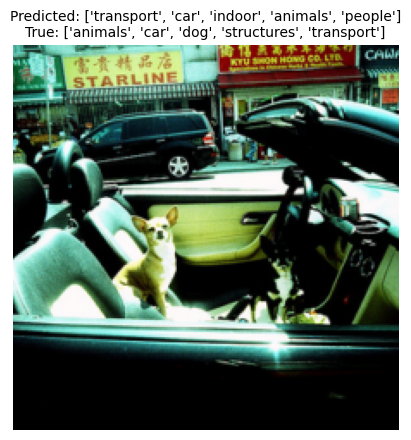

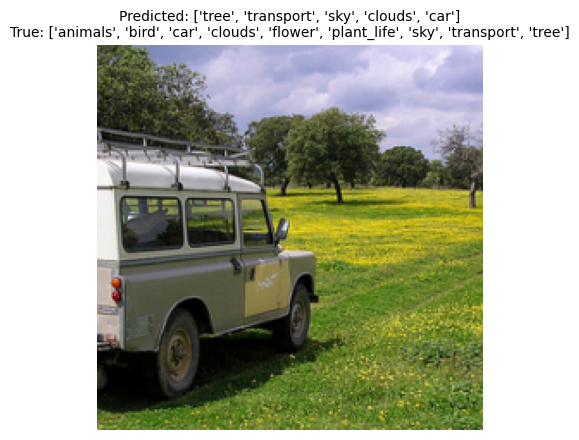

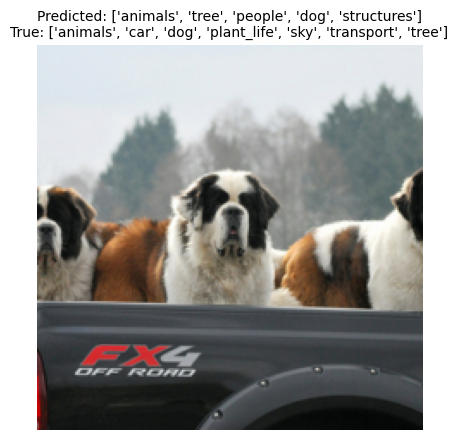

In [10]:
import matplotlib.pyplot as plt

def visualize_predictions(model, loader, label_embeddings, all_labels, num_samples=5, K=5):
    model.eval()
    label_emb_matrix = torch.stack([label_embeddings[lab] for lab in all_labels]).to(device)
    
    # Get a batch of test samples
    images, true_labels_list = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        A_batch = model(images[:num_samples])  # Get predictions for first N samples
    
    # Denormalization transform
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    for i in range(num_samples):
        plt.figure(figsize=(10,5))
        
        # Get image and denormalize
        img = inv_normalize(images[i]).cpu()
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        # Get predictions
        A = A_batch[i]
        scores = torch.max(torch.mm(A, label_emb_matrix.T), dim=0)[0]
        topk_indices = scores.argsort(descending=True)[:K]
        pred_labels = [all_labels[idx] for idx in topk_indices]
        
        # Get true labels
        true_labels = true_labels_list[i]
        
        # Plot
        plt.imshow(img)
        plt.axis('off')
        title = f"Predicted: {pred_labels}\nTrue: {true_labels}"
        plt.title(title, fontsize=10)
        plt.show()

# Usage - add after evaluation
print("\nSample Predictions:")
visualize_predictions(model, test_gzsl_loader, label_embeddings_dict, all_labels, num_samples=3, K=5)


Sample Predictions:


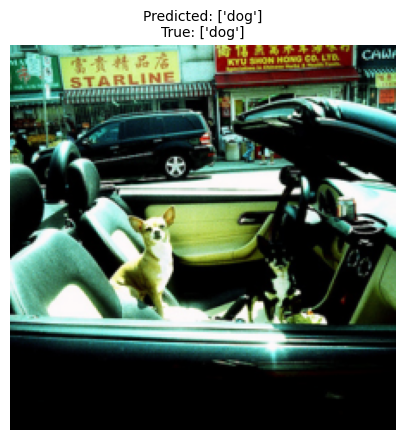

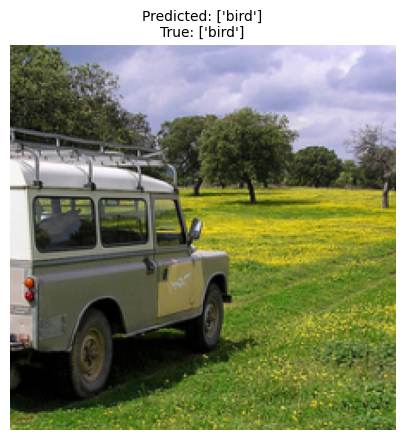

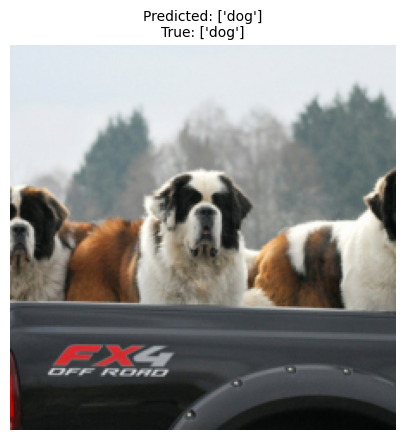

In [11]:
import matplotlib.pyplot as plt

# Change from set to list
seen_labels = list(all_labels[:num_seen])  # Convert to list
unseen_labels = list(all_labels[num_seen:])  # Convert to list

def visualize_zs_predictions(model, loader, label_embeddings, unseen_labels,num_samples=5, K=5):
    model.eval()
    label_emb_matrix = torch.stack([label_embeddings[lab] for lab in unseen_labels]).to(device)
    
    # Get a batch of test samples
    images, true_labels_list = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        A_batch = model(images[:num_samples])  # Get predictions for first N samples
    
    # Denormalization transform
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    for i in range(num_samples):
        plt.figure(figsize=(10,5))
        
        # Get image and denormalize
        img = inv_normalize(images[i]).cpu()
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        # Get predictions
        A = A_batch[i]
        scores = torch.max(torch.mm(A, label_emb_matrix.T), dim=0)[0]
        topk_indices = scores.argsort(descending=True)[:K]
        pred_labels = [unseen_labels[idx] for idx in topk_indices]
        
        # Get true labels
        true_labels = true_labels_list[i]
        
        # Plot
        plt.imshow(img)
        plt.axis('off')
        title = f"Predicted: {pred_labels}\nTrue: {true_labels}"
        plt.title(title, fontsize=10)
        plt.show()

# Usage - add after evaluation
print("\nSample Predictions:")
visualize_zs_predictions(model, test_zs_loader, label_embeddings_dict, unseen_labels, num_samples=3, K=1)